In [95]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from ClassA import RFI_MakeEnvelopeDataClassA
from Estimadores import *
from matplotlib.gridspec import GridSpec

mpl.rc('font',family = 'Times New Roman')

In [104]:
#-------------------------------------------
#----------------- Parámetros --------------
#r = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
#A = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
r = np.logspace(-2,0.8,20)
A = np.logspace(-2,0.8,20)
Sigma_G_sq = 0.001
#-------------------------------------------
#-------------------------------------------
veces = 1
N = 20000
#-----------------------------------
#-----------------------------------
n = np.size(r)
m = np.size(A)
print (r)

[0.01       0.01404004 0.01971228 0.02767612 0.0388574  0.05455595
 0.07659678 0.10754221 0.15098972 0.2119902  0.29763514 0.41788101
 0.58670671 0.82373871 1.15653264 1.62377674 2.27978944 3.20083405
 4.49398459 6.30957344]


In [105]:
# Inicializacion del vector A_ini
vec_A_ini       = np.zeros((veces,m,n))
vec_r_ini       = np.zeros((veces,m,n))
vec_Sigmag2_ini = np.zeros((veces,m,n))

# Inicializacion de los vectores INEMM
A_est_INEMM       = np.zeros((veces,m,n))
Sigmag2_est_INEMM = np.zeros((veces,m,n))
r_est_INEMM       = np.zeros((veces,m,n))

for k in range(veces):
    print('k:', k)
    for j in range(len(r)):
        #print (j)
        for i in range(len(A)):
            #print (i)
            env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A[i],r[j],10,N,Sigma_G_sq)

            # Estimador inicial
            A_ini,Sigmag2_ini,r_ini = est_inicial(env_data_DesNorm)
            vec_A_ini[k,i,j]          = A_ini
            vec_Sigmag2_ini[k,i,j]    = Sigmag2_ini
            vec_r_ini[k,i,j]          = r_ini

            # Estimador INEMM
            A_est_INEMM[k,i,j],Sigmag2_est_INEMM[k,i,j],r_est_INEMM[k,i,j],Numiter_Luc = Est_Param_ClassA_CDF(env_data_DesNorm,[A_ini,Sigmag2_ini,r_ini],500,0.00001)

print ('FIN')

k: 0
FIN


/tmp/ipykernel_22985/3594934920.py:34: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A), vmin = -5, vmax = 1,cmap='Spectral')
/tmp/ipykernel_22985/3594934920.py:46: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r), vmin = -5, vmax = 1,cmap='Spectral')


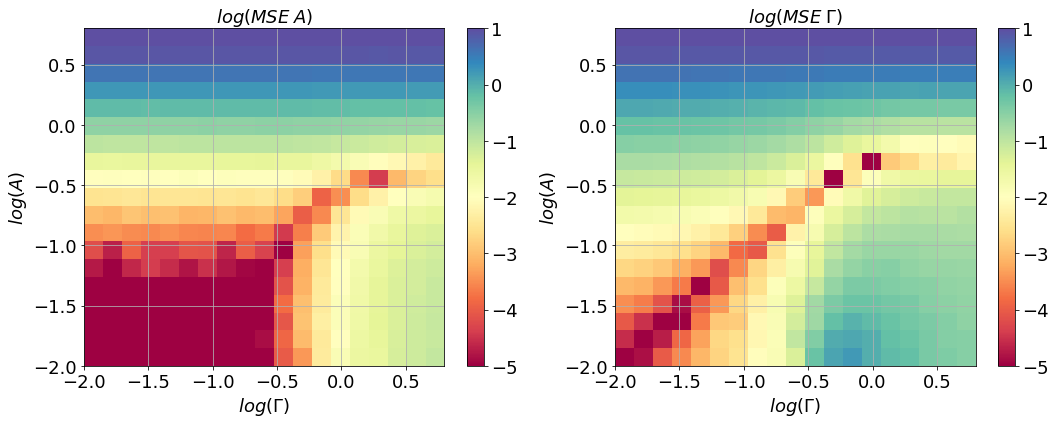

In [106]:
## ------------------ Matriz MSE Simple --------------------------
matriz_A = np.zeros((m,n))
matriz_r = np.zeros((m,n))
matriz_MSE_A = np.zeros((veces,m,n))
matriz_MSE_r = np.zeros((veces,m,n))

for j in range(len(r)):
    for i in range(len(A)):
        matriz_A[i,j] = A[i]
        matriz_r[i,j] = r[i]

for k in range(veces):
    for j in range(len(r)):
        for i in range(len(A)):
            matriz_MSE_A[k,i,j] = (vec_A_ini[k,i,j] - matriz_A[i,j])**2
            matriz_MSE_r[k,i,j] = (vec_r_ini[k,i,j] - matriz_r[i,j])**2
            if matriz_MSE_A[k,i,j] < 0.000001:
                matriz_MSE_A[k,i,j] = 0.0000001


matriz_MSE_A = np.sum(matriz_MSE_A,axis=0)/veces
matriz_MSE_r = np.sum(matriz_MSE_r,axis=0)/veces

# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 6))
gs0 = GridSpec(nrows=1, ncols=2)

ax0 = fig1.add_subplot(gs0[0, 0])
#ax0.title.set_text(r'$log(MSE\;A)$')
ax0.set_title(r'$log(MSE\;A)$', fontsize = 18)
ax0.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax0.set_ylabel('$log(A)$',fontsize = 18)
h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A), vmin = -5, vmax = 1,cmap='Spectral')
cbar0 = fig1.colorbar(h0)
ax0.grid(True)
cbar0.ax.tick_params(labelsize=18)
ax0.tick_params(axis="x", labelsize=18)
ax0.tick_params(axis="y", labelsize=18)

ax1 = fig1.add_subplot(gs0[0, 1])
#ax1.title.set_text(r'$log(MSE\;\Gamma)$')
ax1.set_title(r'$log(MSE\;\Gamma)$', fontsize = 18)
ax1.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax1.set_ylabel('$log(A)$',fontsize = 18)
h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r), vmin = -5, vmax = 1,cmap='Spectral')
cbar = fig1.colorbar(h1)
ax1.grid(True)
cbar.ax.tick_params(labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18)

plt.tight_layout()

fig1.savefig('ErrorEstimacionMapaColor.pdf', bbox_inches = 'tight',pad_inches = 0.1)

/tmp/ipykernel_22985/4001448338.py:27: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A_INEMM), vmin = -5, vmax = 1,cmap='Spectral')
/tmp/ipykernel_22985/4001448338.py:39: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r_INEMM), vmin = -5, vmax = 1,cmap='Spectral')


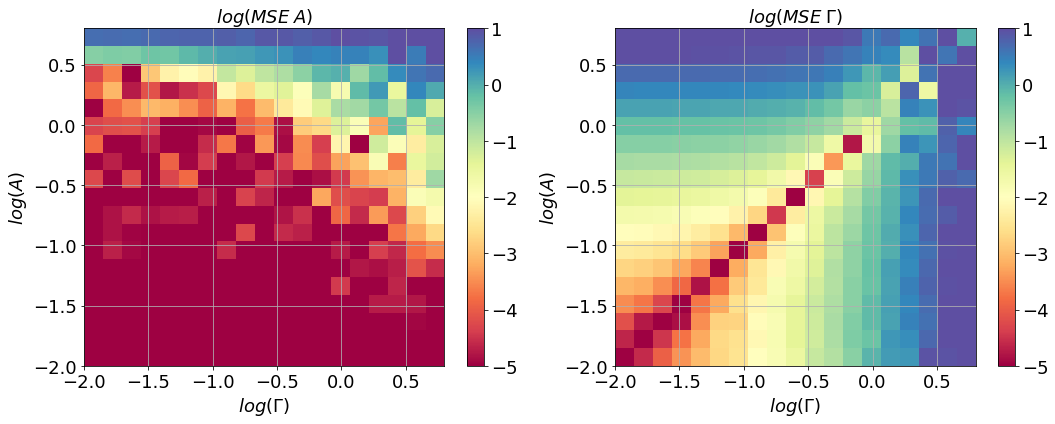

In [107]:
## ------------------ Matriz MSE INEMM --------------------------
matriz_MSE_A_INEMM = np.zeros((veces,m,n))
matriz_MSE_r_INEMM = np.zeros((veces,m,n))

for k in range(veces):
    for j in range(len(r)):
        for i in range(len(A)):
            matriz_MSE_A_INEMM[k,i,j] = (A_est_INEMM[k,i,j] - matriz_A[i,j])**2
            matriz_MSE_r_INEMM[k,i,j] = (r_est_INEMM[k,i,j] - matriz_r[i,j])**2
            if matriz_MSE_A_INEMM[k,i,j] < 0.000001:
                matriz_MSE_A_INEMM[k,i,j] = 0.0000001


matriz_MSE_A_INEMM = np.sum(matriz_MSE_A_INEMM,axis=0)/veces
matriz_MSE_r_INEMM = np.sum(matriz_MSE_r_INEMM,axis=0)/veces

# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 6))
gs0 = GridSpec(nrows=1, ncols=2)

ax0 = fig1.add_subplot(gs0[0, 0])
#ax0.title.set_text(r'$log(MSE\;A)$')
ax0.set_title(r'$log(MSE\;A)$', fontsize = 18)
ax0.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax0.set_ylabel('$log(A)$',fontsize = 18)
h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A_INEMM), vmin = -5, vmax = 1,cmap='Spectral')
cbar0 = fig1.colorbar(h0)
ax0.grid(True)
cbar0.ax.tick_params(labelsize=18)
ax0.tick_params(axis="x", labelsize=18)
ax0.tick_params(axis="y", labelsize=18)

ax1 = fig1.add_subplot(gs0[0, 1])
#ax1.title.set_text(r'$log(MSE\;\Gamma)$')
ax1.set_title(r'$log(MSE\;\Gamma)$', fontsize = 18)
ax1.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax1.set_ylabel('$log(A)$',fontsize = 18)
h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r_INEMM), vmin = -5, vmax = 1,cmap='Spectral')
cbar = fig1.colorbar(h1)
ax1.grid(True)
cbar.ax.tick_params(labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18)

plt.tight_layout()

fig1.savefig('ErrorEstimacionMapaColor.pdf', bbox_inches = 'tight',pad_inches = 0.1)